In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [11]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [12]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [13]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [14]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [15]:
bus_load_kw = bus_load / 0.25
peak_load_kw = bus_load_kw.sum(axis=1).max()

S_base = 1.1 * peak_load_kw   # 10% higher transformer capacity

# convert loads to per unit on this transformer base
bus_load_pu = bus_load_kw / S_base

# Checking if it violates voltage constraint
pf = np.full(bus_load_pu.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - 2.0 * (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Peak load (kW):", peak_load_kw)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage before scaling:", vmin_actual)



Peak load (kW): 464.5039999999999
Transformer rating S_base (kW): 510.95439999999996
Peak load in pu: 0.9090909090909091
Minimum baseline voltage before scaling: 0.902422909575496


In [ ]:
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_pu = bus_load_pu * scale_voltage

v_base = 1.0 - 2.0 * (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Applied voltage scaling factor:", scale_voltage)
print("Minimum baseline voltage after scaling:", vmin_actual)

# Further 20% down
bus_load_pu = 0.8 * bus_load_pu


Applied voltage scaling factor: 0.512415360844207
Minimum baseline voltage after scaling: 0.95


### Hosting Capacity

In [17]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - 2.0 * (Z @ ell)
        denominator = 2.0 * Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [18]:
def solve_cf_order_stat(C_dyn, C_res, lhat_new, K):
    active_idx = np.where(np.isfinite(C_dyn))[0]
    order = np.argsort(C_dyn[active_idx])
    
    C_star = C_dyn[active_idx][order[K]]
    critical_idx = active_idx[order[:K]]

    u_star = np.zeros_like(lhat_new, dtype=float)
    u_star[critical_idx] = C_res[critical_idx] - C_star * lhat_new[critical_idx]

    return C_star, critical_idx, u_star

In [19]:
T = len(bus_load)
lhat = np.ones(T) # Normalized load

# candidate interconnection bus
host_bus_number = 13
host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)

# no flexibility hosting capacity
C0 = np.min(C_dyn[np.isfinite(C_dyn)])

# with K curtailment interventions
K = 350
C_star, critical_idx, u_star = solve_cf_order_stat(C_dyn, C_res, lhat, K)

print("Residual hosting capacity:", C0*5, "MW")
print("Hosting capacity with Curtailment:", C_star*5, "MW")
print("Number of curtailed slots:", len(critical_idx))

Residual hosting capacity: 0.9715308247784255 MW
Hosting capacity with Curtailment: 1.6061176611942738 MW
Number of curtailed slots: 350


### Plotting

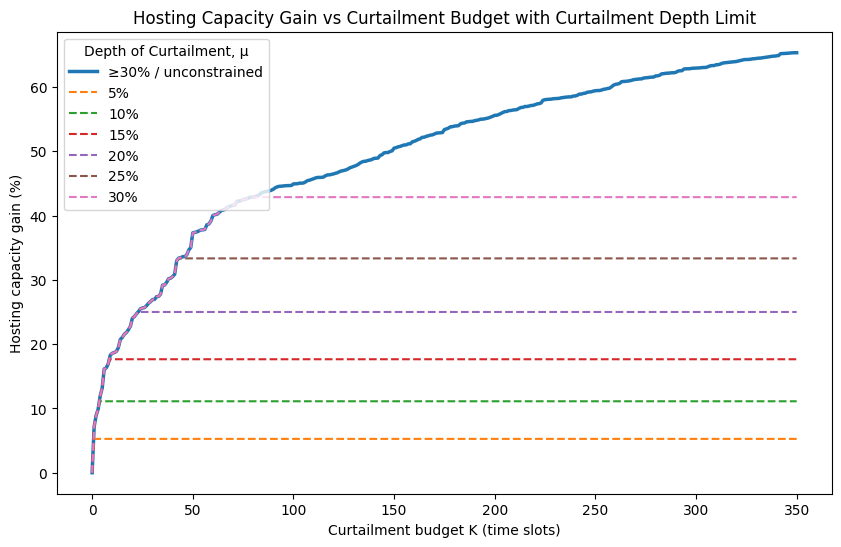

In [26]:
# Active indices where lhat > 0 and C_dyn is finite
active_idx = np.where(np.isfinite(C_dyn))[0]

# Sort active slots by increasing C_dyn
order = np.argsort(C_dyn[active_idx])
sorted_idx = active_idx[order]
sorted_vals = C_dyn[sorted_idx]

T_active = len(sorted_vals)
K_max = 350

# baseline hosting capacity
C0 = sorted_vals[0]
Ks = np.arange(K_max + 1)

# unconstrained curve
Cstars = sorted_vals[Ks]
gains_unconstrained = 100 * (Cstars - C0) / C0

# Constrained Curtailment case
def compute_cstar_with_mu(sorted_idx, sorted_vals, C_res, lhat, Ks, mu):
    Cstars_mu = []

    for K in Ks:
        C_star = sorted_vals[K]
        critical_idx = sorted_idx[:K] # first K slots where curtailment is applied

        if K == 0:
            Cstars_mu.append(C_star)
            continue

        bounds = [C_star]

        # The following logic comes from −u⋆(t)=CK⋆​l^(t)−Cres​(t) and −u⋆(t)≤μCK^* meaning we only can curtail up to μ fraction of the unconstrained curtailment 
        # Then CK⋆​l^(t)−Cres​(t) ≤ μCK^*  => CK⋆​l^(t)−μCK^* ≤ Cres​(t) => CK^*(l^(t)−μ) ≤ Cres​(t) => CK^* ≤ Cres​(t)/(l^(t)−μ)
        # The final equation    C^* ≤ Cres​(t)/(l^(t)−μ)


        for t in critical_idx:
            if lhat[t] > mu:
                bound_t = C_res[t] / (lhat[t] - mu)
                bounds.append(bound_t)


        C_star_mu = min(bounds)
        Cstars_mu.append(C_star_mu)

    return np.array(Cstars_mu)

mu_list = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

plt.figure(figsize=(10, 6))
plt.plot(Ks, gains_unconstrained, linewidth=2.5, label="≥30% / unconstrained")
for mu in mu_list:
    Cstars_mu = compute_cstar_with_mu(sorted_idx, sorted_vals, C_res, lhat, Ks, mu)
    gains_mu = 100 * (Cstars_mu - C0) / C0
    plt.plot(Ks, gains_mu, linestyle="--", label=f"{int(mu*100)}%")

plt.xlabel("Curtailment budget K (time slots)")
plt.ylabel("Hosting capacity gain (%)")
plt.title("Hosting Capacity Gain vs Curtailment Budget with Curtailment Depth Limit")
plt.grid(False)
plt.legend(title="Depth of Curtailment, μ")
plt.show()

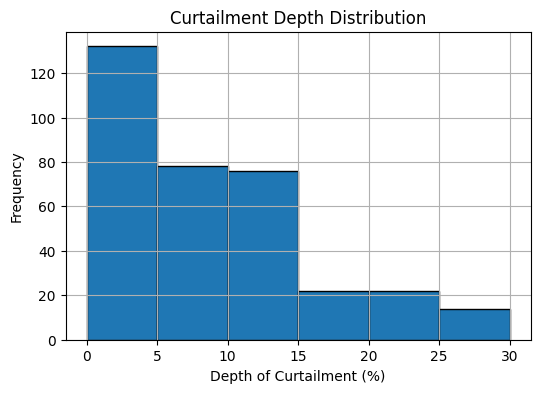

In [28]:
C_star_max= sorted_vals[K_max]
critical_idx = sorted_idx[:K_max]

u_needed = C_star_max * lhat[critical_idx] - C_res[critical_idx]
depth_pct = 100 * u_needed / C_star_max

plt.figure(figsize=(6, 4))
plt.hist(depth_pct, bins=np.arange(0, 31, 5), edgecolor='black')
plt.xlabel("Depth of Curtailment (%)")
plt.ylabel("Frequency")
plt.title("Curtailment Depth Distribution")
plt.grid(True)
plt.show()

### CVAR With No Curtailment Budget

In [33]:
alpha = 0.95
epsilon = 0.0

# Decision variables
C = cp.Variable(nonneg=True, name="C")   # hosting capacity
eta = cp.Variable(name="eta")            # VaR-like auxiliary variable
s = cp.Variable(T, nonneg=True, name="s")# slack for tail losses


constraints = [
    s >= C * lhat - C_res - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
]

# Maximize hosting capacity
obj = cp.Maximize(C)

problem = cp.Problem(obj, constraints)
problem.solve(solver="ECOS", verbose=True)

print("Optimal radial CVaR hosting capacity C:", C.value)
print("In KW :", C.value * S_base)
print("Optimal eta:", eta.value)

(CVXPY) Mar 16 12:11:31 AM: Your problem has 35042 variables, 35041 constraints, and 0 parameters.
(CVXPY) Mar 16 12:11:31 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 16 12:11:31 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 16 12:11:31 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 16 12:11:31 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 16 12:11:31 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 16 12:11:31 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 16 12:11:31 AM: Applying reduction FlipObjective
(CVXPY) Mar 16 12:11:31 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 16 12:11:31 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 16 12:11:31 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 16 12:11:31 AM: Apply

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 16 12:11:31 AM: Problem status: optimal
(CVXPY) Mar 16 12:11:31 AM: Optimal value: 3.479e-01
(CVXPY) Mar 16 12:11:31 AM: Compilation took 1.396e-01 seconds
(CVXPY) Mar 16 12:11:31 AM: Solver (including time spent in interface) took 3.916e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal radial CVaR hosting capacity C: 0.3479103780815234
In KW : 177.76633848641794
Optimal eta: -0.04248596378521682


In [ ]:
## CVAR with curtailment budget


alpha = 0.95
epsilon = 0.0
dt = 0.25      # 15-minute intervals
B_mwh = 25.0   # total curtailed energy budget in MWh
mu = 0.2       # max 20% curtailment per timestamp

C = cp.Variable(nonneg=True, name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, nonneg=True, name="s")
y = cp.Variable(T, nonneg=True, name="y")

zeta = C * lhat - y - c_res

constraints = [
    s >= zeta - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

    y <= C * lhat,          # cannot curtail more than requested load
    y <= mu * C * lhat,     # optional per-slot curtailment cap
    cp.sum(y) * dt <= B_mwh
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal C:", C.value)
print("Total curtailed energy (MWh):", y.value.sum() * dt)

### CVAR with Curtailment Budget

In [38]:
T = len(lhat)


alpha = 0.95
epsilon = 0.0

# Curtailment budget parameters
dt = 0.25      # 15-minute intervals = 0.25 hour
B_kwh = 50   # total curtailment energy budget in MWh
mu = 0.2       # max 20% curtailment per timestamp

# Decision variables
C = cp.Variable(nonneg=True, name="C")     # hosting capacity
eta = cp.Variable(name="eta")              # VaR-like auxiliary variable
s = cp.Variable(T, nonneg=True, name="s")  # CVaR slack variables
y = cp.Variable(T, nonneg=True, name="y")  # curtailed amount at each time

zeta = C * lhat - y - C_res
constraints = [
    # CVaR epigraph constraints
    s >= zeta - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

    # Curtailment feasibility constraints
    y <= C * lhat,          # cannot curtail more than the requested added load
    y <= mu * C * lhat,     # per-slot curtailment cap
    cp.sum(y) * dt <= B_kwh # total curtailment energy budget
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal radial CVaR hosting capacity C (pu):", C.value)
print("Optimal radial CVaR hosting capacity C (KW):", C.value * S_base)   
print("Optimal eta:", eta.value)
print("Total curtailed energy (kWh):", np.sum(y.value) * dt)
print("Max curtailment in any slot (pu):", np.max(y.value))
print("Number of slots with curtailment:", np.sum(y.value > 1e-8))

(CVXPY) Mar 16 12:20:49 AM: Your problem has 70082 variables, 105122 constraints, and 0 parameters.
(CVXPY) Mar 16 12:20:49 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 16 12:20:49 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 16 12:20:49 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 16 12:20:49 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 16 12:20:49 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 16 12:20:49 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 16 12:20:49 AM: Applying reduction FlipObjective
(CVXPY) Mar 16 12:20:49 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 16 12:20:49 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 16 12:20:49 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 16 12:20:49 AM: Appl

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 16 12:20:51 AM: Problem status: optimal
(CVXPY) Mar 16 12:20:51 AM: Optimal value: 4.274e-01
(CVXPY) Mar 16 12:20:51 AM: Compilation took 1.513e-01 seconds
(CVXPY) Mar 16 12:20:51 AM: Solver (including time spent in interface) took 2.156e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal radial CVaR hosting capacity C (pu): 0.42741759043645405
Optimal radial CVaR hosting capacity C (KW): 218.3908984709041
Optimal eta: -0.0209468387492892
Total curtailed energy (kWh): 50.00000000000058
Max curtailment in any slot (pu): 0.08548351808691966
Number of slots with curtailment: 3993
